In [5]:
!pip install -q \
torch==2.8.0 \
torchvision==0.23.0 \
torchaudio==2.8.0 \
transformers==4.55.4 \
datasets==3.6.0 \
accelerate==1.10.1 \
evaluate==0.4.5 \
sentencepiece

In [6]:
import torch
import torchvision
import transformers
import datasets
import accelerate
import evaluate
import huggingface_hub

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("accelerate:", accelerate.__version__)
print("evaluate:", evaluate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

torch: 2.8.0+cu128
torchvision: 0.23.0+cu128
transformers: 4.55.4
datasets: 3.6.0
accelerate: 1.10.1
evaluate: 0.4.5
huggingface_hub: 0.36.2


In [7]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [8]:
import pandas as pd
import numpy as np
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split

from transformers import(
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [9]:
from google.colab import files
uploaded = files.upload()

Saving processed_dataset.csv to processed_dataset (2).csv


In [10]:
df = pd.read_csv("processed_dataset.csv")
df.head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Lea...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [11]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

In [12]:
train_dataset= Dataset.from_pandas(train_df)
val_dataset= Dataset.from_pandas(val_df)
test_dataset= Dataset.from_pandas(test_df)

In [13]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [14]:
def tokenize_function(example):
  return tokenizer(
      example["content"],
      padding="max_length",
      truncation=True,
      max_length=256
  )

In [16]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/31428 [00:00<?, ? examples/s]

Map:   0%|          | 0/6735 [00:00<?, ? examples/s]

Map:   0%|          | 0/6735 [00:00<?, ? examples/s]

In [17]:
tokenized_train = tokenized_train.remove_columns(
    ["content","__index_level_0__"]
)

tokenized_val = tokenized_val.remove_columns(
    ["content","__index_level_0__"]
)

tokenized_test = tokenized_test.remove_columns(
    ["content","__index_level_0__"]
)

In [18]:
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

In [19]:
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

In [20]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

In [22]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred

  predictions = np.argmax(logits, axis=-1)
  acc = accuracy.compute(predictions=predictions, references=labels)
  f1_score = f1.compute(predictions=predictions, references=labels)

  return {
      "accracy": acc["accuracy"],
      "f1": f1_score["f1"]
  }

In [23]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./models/distilbert_fake_news",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)


In [24]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics

)

In [25]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [26]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accracy,F1
1,0.005800,0.004685,0.999258,0.999221
2,0.001100,0.002031,0.999555,0.999533
3,0.000000,0.001068,0.999852,0.999844


TrainOutput(global_step=5895, training_loss=0.0051763277876872545, metrics={'train_runtime': 677.9441, 'train_samples_per_second': 139.073, 'train_steps_per_second': 8.695, 'total_flos': 6244778107441152.0, 'train_loss': 0.0051763277876872545, 'epoch': 3.0})

In [27]:
!nvidia-smi

Wed Jul 22 17:50:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             31W /   70W |    2025MiB /  15360MiB |     12%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [28]:
results = trainer.evaluate(tokenized_test)
print(results)

{'eval_loss': 0.0012748967856168747, 'eval_accracy': 0.9997030438010394, 'eval_f1': 0.9996885705387729, 'eval_runtime': 12.1762, 'eval_samples_per_second': 553.127, 'eval_steps_per_second': 34.576, 'epoch': 3.0}


In [29]:
predictions = trainer.predict(tokenized_test)

In [30]:
import numpy as np
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

print("Number of predictions: ",len(y_pred))
print("Number of true labels:",len(y_true))

Number of predictions:  6735
Number of true labels: 6735


In [31]:
from sklearn.metrics import classification_report
print(classification_report(
    y_true,
    y_pred,
    target_names=["real","fake"]
 )
)

              precision    recall  f1-score   support

        real       1.00      1.00      1.00      3523
        fake       1.00      1.00      1.00      3212

    accuracy                           1.00      6735
   macro avg       1.00      1.00      1.00      6735
weighted avg       1.00      1.00      1.00      6735



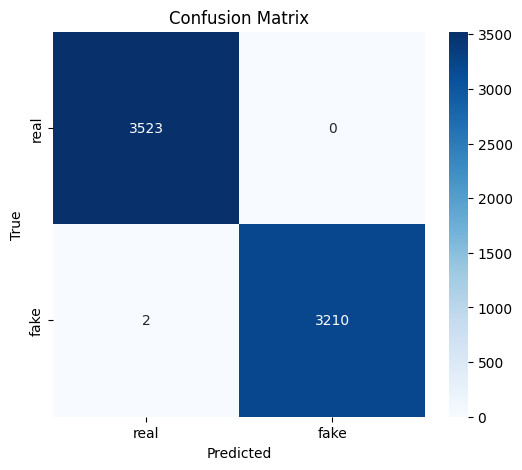

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["real","fake"],
    yticklabels=["real","fake"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [33]:
trainer.save_model("./final_model")
tokenizer.save_pretrained("./final_model")

('./final_model/tokenizer_config.json',
 './final_model/special_tokens_map.json',
 './final_model/vocab.txt',
 './final_model/added_tokens.json')

In [34]:
import os
os.listdir("./final_model")

['special_tokens_map.json',
 'vocab.txt',
 'config.json',
 'tokenizer_config.json',
 'training_args.bin',
 'model.safetensors']

In [35]:
!zip -r final_model.zip final_model

  adding: final_model/ (stored 0%)
  adding: final_model/special_tokens_map.json (deflated 42%)
  adding: final_model/vocab.txt (deflated 53%)
  adding: final_model/config.json (deflated 45%)
  adding: final_model/tokenizer_config.json (deflated 75%)
  adding: final_model/training_args.bin (deflated 53%)
  adding: final_model/model.safetensors (deflated 8%)


In [36]:
from google.colab import files
files.download("./final_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>